# 01 — EDA

Per the brief's "first concrete action": distributions, missingness, and
class balance of frost vs. non-frost under the chosen threshold — on the
Tier-1 dataset, before touching any model code.

This notebook does EDA only. Label computation itself lives in
`src/label_rules.py` / `02_label_definition.ipynb` — duplicating the
threshold logic here as well would create exactly the kind of drift risk
the brief warns about for `features.py`, just one file earlier.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd

from data_loader import load_tier1_raw, get_city_frame, list_cities, missingness_report
from label_rules import build_labels_for_horizon
from features import add_dew_point_features

In [2]:
raw = load_tier1_raw('../data/raw/weather_prediction_dataset.csv')
print(f"Shape: {raw.shape}")
print(f"Date range: {raw['DATE'].min().date()} to {raw['DATE'].max().date()}")
print(f"Cities ({len(list_cities(raw))}): {list_cities(raw)}")

Shape: (3654, 165)
Date range: 2000-01-01 to 2010-01-01
Cities (18): ['BASEL', 'BUDAPEST', 'DE_BILT', 'DRESDEN', 'DUSSELDORF', 'HEATHROW', 'KASSEL', 'LJUBLJANA', 'MAASTRICHT', 'MALMO', 'MONTELIMAR', 'MUENCHEN', 'OSLO', 'PERPIGNAN', 'ROMA', 'SONNBLICK', 'STOCKHOLM', 'TOURS']


## Missingness

Explicit check, not an assumption — the brief calls this out specifically.

In [3]:
missing = missingness_report(raw)
print(f"Total missing values across the whole dataset: {missing.sum()}")
missing[missing > 0]

Total missing values across the whole dataset: 0


Series([], dtype: int64)

No missing values anywhere in this Tier-1 export — worth stating explicitly
in the report rather than leaving it unchecked, since that won't be true of
every tier (Tier 2/3 real-station data is much more likely to have gaps).

## Distributions — Basel as the representative city

In [4]:
CITY = 'BASEL'
city_df = get_city_frame(raw, CITY)
city_df.describe().round(2)

,DATE,cloud_cover,humidity,pressure,global_radiation,precipitation,sunshine,temp_mean,temp_min,temp_max,humidity_pct
count,3654,3654.00,3654.00,3654.00,3654.00,3654.00,3654.00,3654.00,3654.00,3654.00,3654.00
mean,2004-12-31 12:00:00,5.42,0.75,1.02,1.33,0.23,4.66,11.02,6.99,15.54,74.51
min,2000-01-01 00:00:00,0.00,0.38,0.99,0.05,0.00,0.00,-9.30,-16.00,-5.70,38.00
25%,2002-07-02 06:00:00,4.00,0.67,1.01,0.53,0.00,0.50,5.30,2.00,8.70,67.00
50%,2004-12-31 12:00:00,6.00,0.76,1.02,1.11,0.00,3.60,11.40,7.30,15.80,76.00
75%,2007-07-02 18:00:00,7.00,0.83,1.02,2.06,0.21,8.00,16.90,12.40,22.30,83.00
max,2010-01-01 00:00:00,8.00,0.98,1.04,3.55,7.57,15.30,29.00,20.80,38.60,98.00
std,NaN,2.33,0.11,0.01,0.94,0.54,4.33,7.41,6.65,8.72,10.78


<Axes: title={'center': 'BASEL daily temperatures, 2000-2010'}>

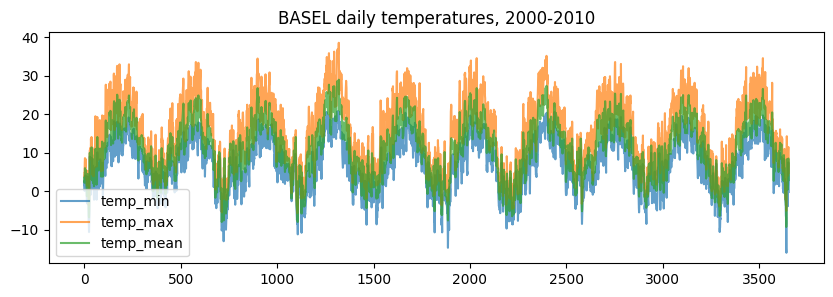

In [5]:
city_df[['temp_min', 'temp_max', 'temp_mean']].plot(
    figsize=(10, 3), title=f'{CITY} daily temperatures, 2000-2010', alpha=0.7
)

**Units check** (see `features.py`'s unit warning): `humidity` here is a
0-1 FRACTION, not a percentage, and `cloud_cover` is in oktas (0-8), not
percent. `get_city_frame` already derives `humidity_pct` (0-100) to avoid
silently feeding the wrong scale into a dew-point calculation later.

In [6]:
city_df[['humidity', 'humidity_pct', 'cloud_cover']].describe().round(2)

,humidity,humidity_pct,cloud_cover
count,3654.00,3654.00,3654.00
mean,0.75,74.51,5.42
std,0.11,10.78,2.33
min,0.38,38.00,0.00
25%,0.67,67.00,4.00
50%,0.76,76.00,6.00
75%,0.83,83.00,7.00
max,0.98,98.00,8.00


## Class balance under the project's threshold(s)

Using `label_rules.build_labels_for_horizon` (the same function
`02_label_definition.ipynb` uses) rather than a separate inline
threshold, so this number can't drift from the one actually used
downstream.

In [7]:
city_df = add_dew_point_features(city_df, temp_col='temp_min', rh_percent_col='humidity_pct')
labeled = build_labels_for_horizon(city_df, horizon=1)

n = len(labeled)
n_broad = labeled['frost_label_broad'].sum()
n_strict = labeled['frost_label_strict'].sum()

print(f"{CITY}, 1-day horizon, {n} rows")
print(f"Broad  (Tmin<3C):           {n_broad} events ({100*n_broad/n:.1f}%) -> class imbalance ~{n/n_broad:.1f}:1")
print(f"Strict (Tmin<3C AND Td<0C): {n_strict} events ({100*n_strict/n:.1f}%) -> class imbalance ~{n/n_strict:.1f}:1")

BASEL, 1-day horizon, 3653 rows
Broad  (Tmin<3C):           1083 events (29.6%) -> class imbalance ~3.4:1
Strict (Tmin<3C AND Td<0C): 1011 events (27.7%) -> class imbalance ~3.6:1


Both variants land well under 50% positive, as expected for frost — this
is the class imbalance the brief warns will make a naive direct classifier
misleadingly accurate (Phase 1 baselines / Phase 3 models handle this via
regression-then-threshold; see `03_baselines.ipynb`).

## Quick look across all 18 cities

Not every station reports the same variables (e.g. Basel has no wind
columns) — worth knowing before Phase 2 feature engineering picks a
feature set that has to exist for every city being modeled.

In [8]:
summary_rows = []
skipped_cities = []
for city in list_cities(raw):
    cdf = get_city_frame(raw, city)
    if 'temp_min' not in cdf.columns:
        skipped_cities.append(city)
        continue
    summary_rows.append({
        'city': city,
        'has_wind': 'wind_speed' in cdf.columns,
        'temp_min_mean': cdf['temp_min'].mean(),
        'temp_min_min': cdf['temp_min'].min(),
        'pct_below_3C': 100 * (cdf['temp_min'] < 3.0).mean(),
    })

if skipped_cities:
    print(f"Skipped (no temp_min column at all): {skipped_cities}")

pd.DataFrame(summary_rows).round(2).sort_values('pct_below_3C', ascending=False)

Skipped (no temp_min column at all): ['BUDAPEST']


,city,has_wind,temp_min_mean,temp_min_min,pct_below_3C
14,SONNBLICK,False,-6.88,-30.3,92.88
11,OSLO,True,3.85,-20.7,47.24
15,STOCKHOLM,False,5.10,-19.7,41.41
10,MUENCHEN,True,6.00,-16.4,35.06
2,DRESDEN,True,5.92,-20.4,34.89
5,KASSEL,True,5.59,-19.0,34.59
8,MALMO,True,5.66,-19.5,34.46
6,LJUBLJANA,True,7.07,-16.2,31.53
0,BASEL,False,6.99,-16.0,29.20
1,DE_BILT,True,6.40,-14.4,27.86


**Takeaway for later phases:** wind coverage is inconsistent across
stations (flagged as an open question for Repo B's sensor choice in the
brief), and the fraction of cold days varies a lot by city/climate —
worth keeping in mind when picking which city(ies) to train the Phase 3
models on, versus which to hold out as a transfer/generalization check.
Also: not every station even reports `temp_min` — Budapest in this export only has `temp_mean`/`temp_max`, so it is excluded from the table above and would need `temp_min` approximated (or be dropped) if it were ever used as a training or transfer city.